In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Folder to save charts for PowerPoint Presentation
OUT = Path("figs_netflix")
OUT.mkdir(exist_ok=True)

In [3]:
# Helper to style plots consistently
def finalize(ax, title=None, xlabel=None, ylabel=None):
    ax.set_title(title or "", pad=12, fontsize=12, weight="bold")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

In [4]:
# Define paths and load data
most_popular_path = Path("most-popular-netflix.xlsx")
countries_path = Path("all-weeks-countries-netflix.xlsx")
global_path = Path("all-weeks-global-netflix.xlsx")

# Read the three datasets into DataFrames
mp_df   = pd.read_excel(most_popular_path)
ctry_df = pd.read_excel(countries_path)
glob_df = pd.read_excel(global_path)

# Preview
print("most-popular columns:", list(mp_df.columns))
print("countries columns:", list(ctry_df.columns))
print("global columns:", list(glob_df.columns))

display(mp_df.head())
display(ctry_df.head())
display(glob_df.head())

/Users/dmalvarado/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/dmalvarado/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/dmalvarado/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


most-popular columns: ['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days']
countries columns: ['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']
global columns: ['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'runtime', 'weekly_views', 'cumulative_weeks_in_top_10', 'is_staggered_launch', 'episode_launch_details']


,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN


In [5]:
# Create Helper Functions:
def normalize_category(s: pd.Series) -> pd.Series:
    """
    Map labels to {TV, Films, Other}.
    """
    s = s.astype(str).str.strip().str.lower()
    s = (s
         .replace({
             "tv shows": "tv", "television": "tv",
             "tv (english)": "tv", "tv (non-english)": "tv",
             "films (english)": "films", "films (non-english)": "films",
             "movie": "films", "movies": "films", "film": "films"
         }))
    return np.where(s.eq("tv"), "TV",
           np.where(s.eq("films"), "Films", "Other"))

def compose_title(df: pd.DataFrame, show_col="show_title", season_col="season_title") -> pd.Series:
    """
    Prefer season_title if present, else use show_title.
    """
    season = df.get(season_col)
    show   = df.get(show_col)
    has_season = season.notna() & (season.astype(str).str.strip() != "")
    return np.where(has_season, season.astype(str).str.strip(), show.astype(str).str.strip())

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

# GLOBAL weekly dataset standardization
glob_std = glob_df.copy()

# Dates
glob_std["week"] = pd.to_datetime(glob_std["week"], errors="coerce")

# Titles
glob_std["title"] = compose_title(glob_std, "show_title", "season_title")
glob_std["title"] = glob_std["title"].str.strip()

# Category
glob_std["category"] = normalize_category(glob_std["category"])

# Core metrics
glob_std["hours_viewed"] = to_num(glob_std["weekly_hours_viewed"])
glob_std["views"]        = to_num(glob_std["weekly_views"])
glob_std["weekly_rank"]  = to_num(glob_std["weekly_rank"])

# Useful flags
glob_std["is_staggered_launch"] = glob_std["is_staggered_launch"].fillna(False).astype(bool)

# COUNTRIES weekly dataset standardization
ctry_std = ctry_df.copy()

# Country columns
ctry_std = ctry_std.rename(columns={
    "country_name": "country",
    "country_iso2": "iso2"
})

# Dates
ctry_std["week"] = pd.to_datetime(ctry_std["week"], errors="coerce")

# Title
ctry_std["title"]    = compose_title(ctry_std, "show_title", "season_title")
ctry_std["title"]    = ctry_std["title"].str.strip()

# Category
ctry_std["category"] = normalize_category(ctry_std["category"])

# Rank / cumulative weeks
ctry_std["weekly_rank"]                 = to_num(ctry_std["weekly_rank"])
ctry_std["cumulative_weeks_in_top_10"]  = to_num(ctry_std["cumulative_weeks_in_top_10"])

# Country strings
ctry_std["country"] = ctry_std["country"].astype(str).str.strip()
ctry_std["iso2"]    = ctry_std["iso2"].astype(str).str.strip().str.upper()

# MOST-POPULAR (all-time) dataset standardization
mp_std = mp_df.copy()

# Title
mp_std["title"]    = compose_title(mp_std, "show_title", "season_title")
mp_std["title"]    = mp_std["title"].str.strip()

# Category
mp_std["category"] = normalize_category(mp_std["category"])

# Metrics: 91-day windows
mp_std["rank"]                     = to_num(mp_std["rank"])
mp_std["hours_viewed"]             = to_num(mp_std["hours_viewed_first_91_days"])
mp_std["views"]                    = to_num(mp_std["views_first_91_days"])
mp_std["runtime"]                  = to_num(mp_std["runtime"])

# Remove duplicate rows and sort
glob_std = glob_std.drop_duplicates(subset=["week", "title", "category", "weekly_rank"]).sort_values(["week","weekly_rank"])
ctry_std = ctry_std.drop_duplicates(subset=["week", "country", "title", "weekly_rank"]).sort_values(["week","country","weekly_rank"])
mp_std   = mp_std.drop_duplicates(subset=["title", "category"]).sort_values(["rank"])

# Check and confirm changes
print("GLOBAL (standardized) — columns:", list(glob_std.columns))
display(glob_std.head(3))
print("COUNTRIES (standardized) — columns:", list(ctry_std.columns))
display(ctry_std.head(3))
print("MOST-POPULAR (standardized) — columns:", list(mp_std.columns))
display(mp_std.head(3))

GLOBAL (standardized) — columns: ['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'runtime', 'weekly_views', 'cumulative_weeks_in_top_10', 'is_staggered_launch', 'episode_launch_details', 'title', 'hours_viewed', 'views']


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details,title,hours_viewed,views
5800,2021-07-04,Films,1,Fatherhood,NaN,25680000,NaN,NaN,1,False,NaN,Fatherhood,25680000,NaN
5810,2021-07-04,Films,1,Silver Skates,NaN,7390000,NaN,NaN,1,False,NaN,Silver Skates,7390000,NaN
5820,2021-07-04,TV,1,Sex/Life,Sex/Life: Season 1,86730000,NaN,NaN,1,False,NaN,Sex/Life: Season 1,86730000,NaN


COUNTRIES (standardized) — columns: ['country', 'iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10', 'title']


,country,iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10,title
2900,Argentina,AR,2021-07-04,Films,1,Fatale,NaN,1,Fatale
2910,Argentina,AR,2021-07-04,TV,1,"Newly Rich, Newly Poor","Newly Rich, Newly Poor: Season 1",1,"Newly Rich, Newly Poor: Season 1"
2901,Argentina,AR,2021-07-04,Films,2,Fatherhood,NaN,1,Fatherhood


MOST-POPULAR (standardized) — columns: ['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days', 'title', 'hours_viewed', 'views']


,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days,title,hours_viewed,views
0,Films,1,Red Notice,NaN,454200000,1.9667,230900000,Red Notice,454200000,230900000
30,TV,1,Squid Game,Squid Game: Season 1,2205200000,8.3167,265200000,Squid Game: Season 1,2205200000,265200000
10,Films,1,Troll,NaN,178600000,1.7333,103000000,Troll,178600000,103000000


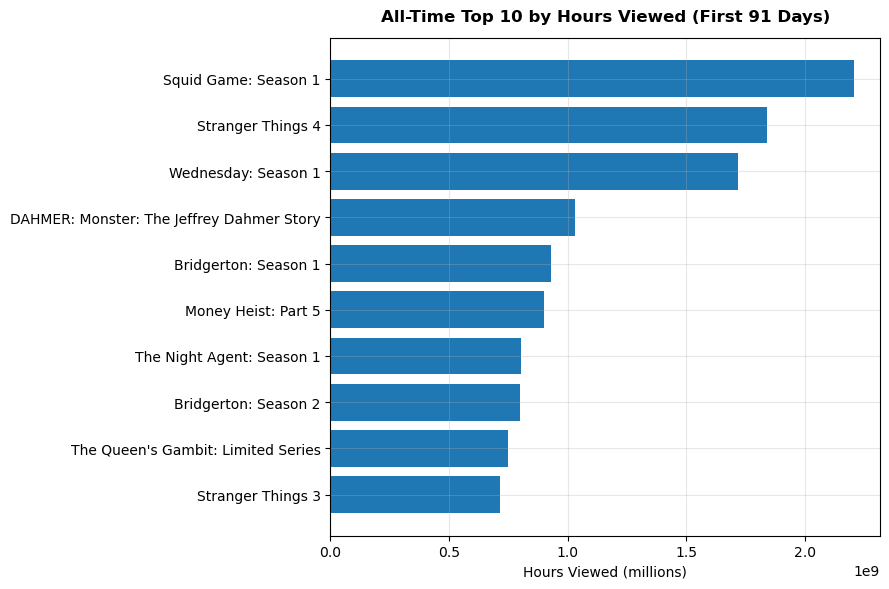

In [6]:
# Visual 1: All-Time Top 10 Titles by Hours Viewed (First 91 Days)

# Select top 10 titles ranked by hours_viewed
top10 = (
    mp_std
    .dropna(subset=["hours_viewed"])
    .sort_values("hours_viewed", ascending=False)
    .head(10)
)
# Horizontal bar chart 
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(top10["title"][::-1], top10["hours_viewed"][::-1])  # reverse for top-to-bottom
finalize(
    ax,
    title="All-Time Top 10 by Hours Viewed (First 91 Days)",
    xlabel="Hours Viewed (millions)",
    ylabel=""
)
# Save and display plot
plt.savefig(OUT / "v1_alltime_top10.png", dpi=200)
plt.show()

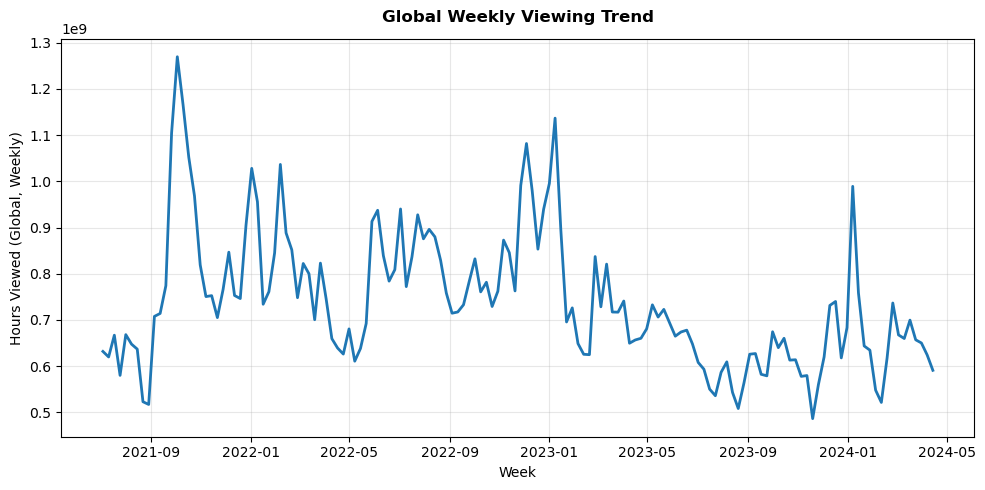

In [7]:
# Visual 2: Global Weekly Viewing Trend (Hours Viewed)

# Aggregate global weekly hours viewed
trend = (
    glob_std
    .dropna(subset=["week","hours_viewed"])
    .groupby("week", as_index=False)["hours_viewed"]
    .sum()
    .sort_values("week")
)
# Line plot of weekly global viewing hours
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(trend["week"], trend["hours_viewed"], linewidth=2)

finalize(
    ax,
    title="Global Weekly Viewing Trend",
    xlabel="Week",
    ylabel="Hours Viewed (Global, Weekly)"
)
# Save and display plot
plt.savefig(OUT / "v2_global_trend.png", dpi=200)
plt.show()

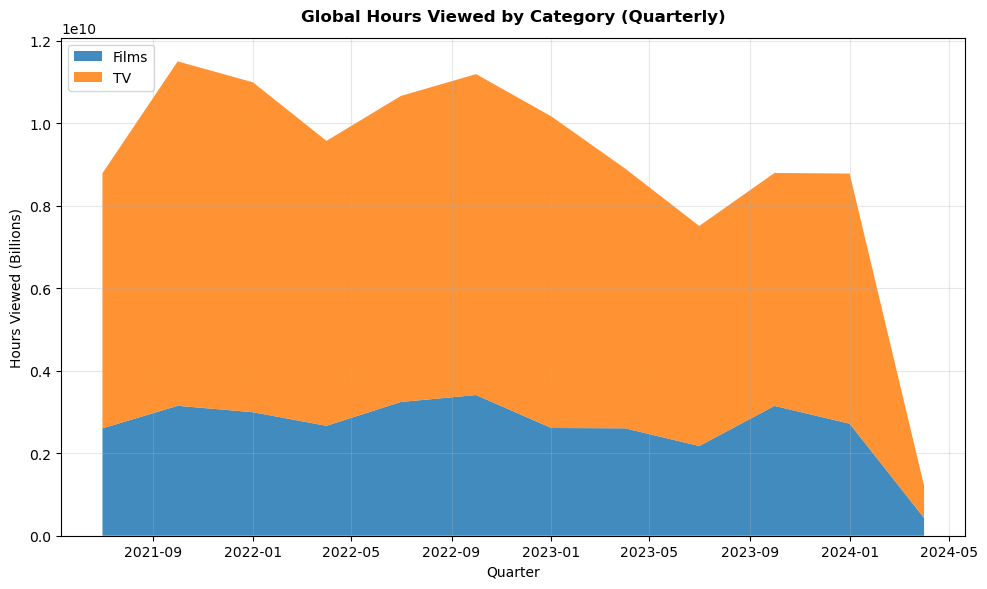

In [8]:
# Visual 3: Global Hours by Category (Quarterly)

gt = glob_std.dropna(subset=["week","hours_viewed","category"]).copy()

# Add a quarterly time bucket
gt["quarter"] = gt["week"].dt.to_period("Q").dt.to_timestamp()

# Sum hours by quarter + category
q = (gt.groupby(["quarter","category"], as_index=False)["hours_viewed"].sum())

# Pivot so categories become columns
pivot = q.pivot(index="quarter", columns="category", values="hours_viewed").fillna(0)

# Stacked area chart of hours viewed by category
fig, ax = plt.subplots(figsize=(10,6))
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns, alpha=0.85)
ax.legend(loc="upper left")
finalize(ax,
    title="Global Hours Viewed by Category (Quarterly)",
    xlabel="Quarter",
    ylabel="Hours Viewed (Billions)"
)
# Save and display plot
plt.savefig(OUT / "v3_category_share.png", dpi=200)
plt.show()

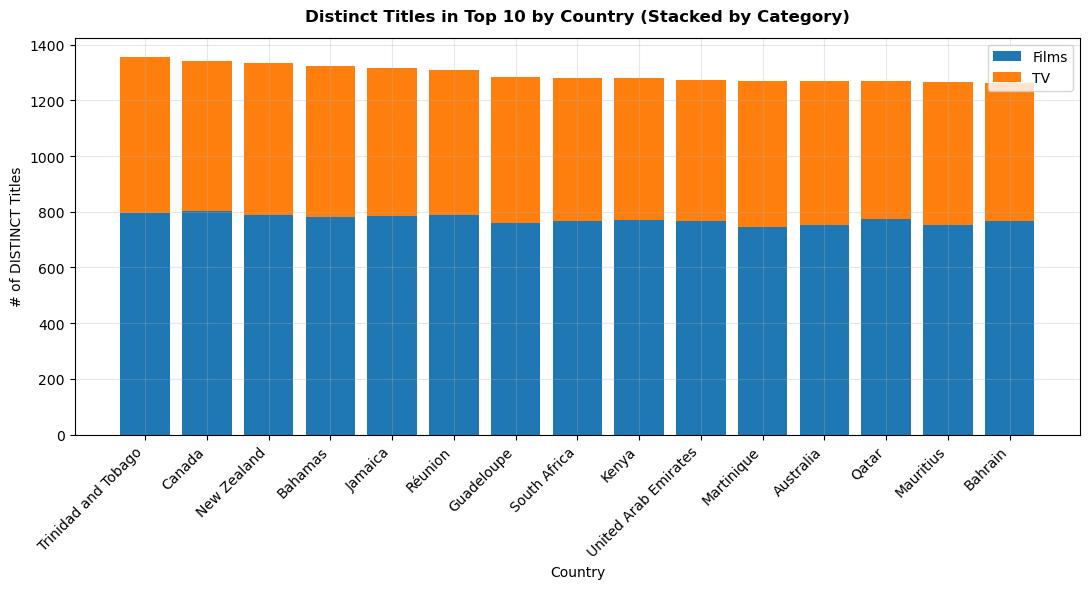

In [9]:
# Visual 4: Distinct titles reaching Top 10 by country (stacked Films vs TV)

# Start from the standardized countries DF
cc = ctry_std.dropna(subset=["country","category","week","title"]).copy()

# Keep only Top-10 rows
cc = cc[cc["weekly_rank"] <= 10]

# Count DISTINCT titles that ever reached Top 10 per country and category
distinct_counts = (
    cc.groupby(["country","category"])["title"]
      .nunique()
      .reset_index(name="distinct_titles")
)

# Choose top countries by overall distinct titles (Films + TV summed)
overall = (distinct_counts.groupby("country")["distinct_titles"]
           .sum()
           .sort_values(ascending=False))

top_countries = overall.head(15).index

# Country x category matrix for the selected countries
bars = (
    distinct_counts[distinct_counts["country"].isin(top_countries)]
    .pivot(index="country", columns="category", values="distinct_titles")
    .fillna(0)
)

# Ensure expected columns exist
desired_cols = [c for c in ["Films", "TV"] if c in bars.columns]
# If neither exists keep what is there
if not desired_cols:
    desired_cols = list(bars.columns)
bars = bars[desired_cols]

# Sort rows by total, then by TV where present
bars["_total"] = bars.sum(axis=1)
sort_keys = ["_total"] + (["TV"] if "TV" in bars.columns else [])
bars = bars.sort_values(by=sort_keys, ascending=False).drop(columns=["_total"])

# Plot stacked bars
fig, ax = plt.subplots(figsize=(11,6))
bottom = None
for col in bars.columns:  # e.g., Films, TV
    ax.bar(bars.index, bars[col], bottom=bottom, label=col)
    bottom = bars[col] if bottom is None else (bottom + bars[col])

ax.legend()
plt.xticks(rotation=45, ha="right")
finalize(
    ax,
    title="Distinct Titles in Top 10 by Country (Stacked by Category)",
    xlabel="Country",
    ylabel="# of DISTINCT Titles"
)
# Save and display plot
plt.savefig(OUT / "v4_country_stacked_distinct_titles.png", dpi=200)
plt.show()

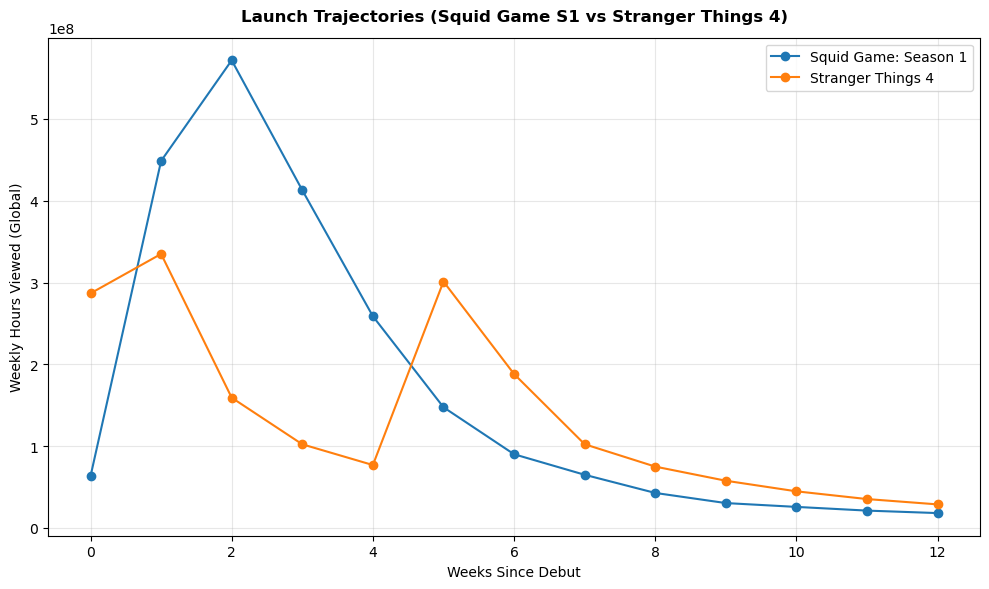

In [10]:
# Visual 5: Compare Squid Game S1 vs Stranger Things 4

# Define function - align a show's weekly viewing to its debut week
def aligned_trajectory(df, title, weeks=12):
    """
    Extract weekly hours viewed for a given title, aligned to its debut week.
    Keeps only the first `weeks` weeks after launch.
    """
    d = df[df["title"].str.contains(title, case=False, na=False)].copy()
    d = d.sort_values("week")
    if d.empty:
        return pd.DataFrame(columns=["aligned_week","hours_viewed","title"])
    
    # Align weeks since debut
    d["aligned_week"] = (d["week"] - d["week"].min()).dt.days // 7
    d["title"] = title
    
    return d.loc[d["aligned_week"] <= weeks, ["aligned_week","hours_viewed","title"]]

# Aligned trajectories for Squid Game S1 and Stranger Things 4
sg = aligned_trajectory(glob_std, "Squid Game: Season 1", weeks=12)
st4 = aligned_trajectory(glob_std, "Stranger Things 4", weeks=12)

# Combine into single DataFrame
case_df = pd.concat([sg, st4], ignore_index=True)

# Plot trajectories
fig, ax = plt.subplots(figsize=(10,6))
for t, sub in case_df.groupby("title"):
    ax.plot(sub["aligned_week"], sub["hours_viewed"], marker="o", label=t)

ax.legend()
finalize(ax,
    title="Launch Trajectories (Squid Game S1 vs Stranger Things 4)",
    xlabel="Weeks Since Debut",
    ylabel="Weekly Hours Viewed (Global)"
)
# Save and display plot
plt.savefig(OUT / "v5_case_study_sg_vs_st4.png", dpi=200)
plt.show()

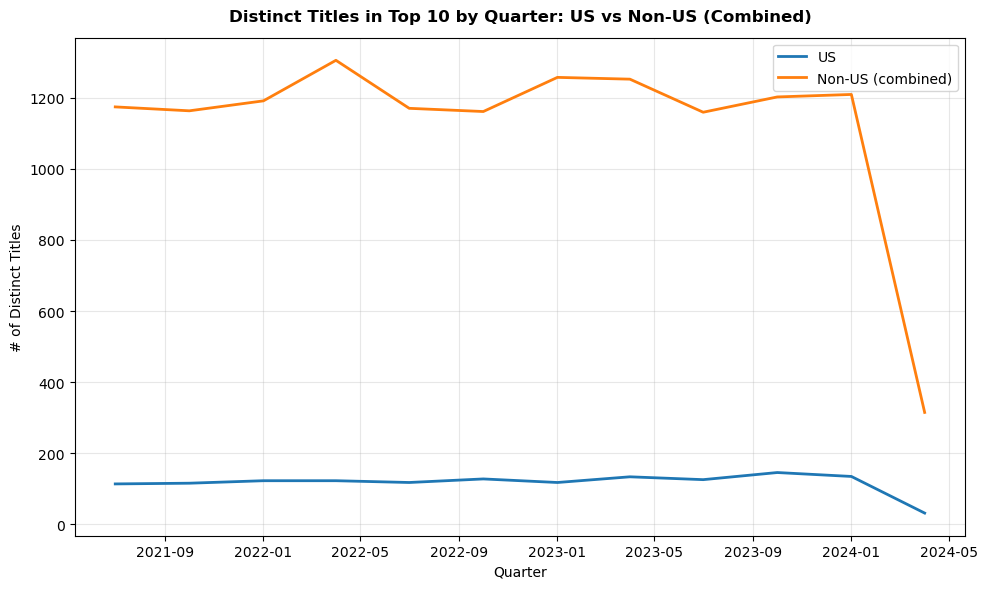

In [11]:
# Visual 6: US vs Non-US breadth of Top-10 titles (quarterly distinct titles)

cc = ctry_std.dropna(subset=["country","week","title"]).copy()
cc = cc[cc["weekly_rank"] <= 10] # only Top 10 titles

# Region flag
cc["region"] = np.where(cc["country"] == "United States", "US", "Non-US")

# Quarterly time bucket
cc["quarter"] = cc["week"].dt.to_period("Q").dt.to_timestamp()

# Count DISTINCT titles per quarter and region
quarterly = (
    cc.groupby(["quarter","region"])["title"]
      .nunique()
      .reset_index(name="distinct_titles")
)

# Pivot to wide format - 1 column per region
pivot = quarterly.pivot(index="quarter", columns="region", values="distinct_titles").fillna(0)

# Plot US vs Non-US trend lines
fig, ax = plt.subplots(figsize=(10,6))
if "US" in pivot.columns:
    ax.plot(pivot.index, pivot["US"], label="US", linewidth=2)
if "Non-US" in pivot.columns:
    ax.plot(pivot.index, pivot["Non-US"], label="Non-US (combined)", linewidth=2)

ax.legend()
finalize(
    ax,
    title="Distinct Titles in Top 10 by Quarter: US vs Non-US (Combined)",
    xlabel="Quarter",
    ylabel="# of Distinct Titles"
)
# Save and display plot
plt.savefig(OUT / "v6_us_vs_nonus_quarterly_distinct_titles.png", dpi=200)
plt.show()